# Data Preprocessing and Dataset Preparation

## Objective

The purpose of this notebook is to transform the raw CPCB air quality dataset into a clean, analysis-ready dataset.

The preprocessing workflow includes:

* Dataset inspection
* Data quality assessment
* Missing value analysis
* Invalid AQI removal
* Feature removal
* Missing value treatment
* Feature engineering
* Export of the cleaned dataset

The resulting dataset will be used consistently across all subsequent Python notebooks, SQL analysis, and Power BI dashboards.


## Import Required Libraries

The analysis begins by importing Python libraries used for data manipulation, visualization, and exploratory analysis.

* Pandas: Data manipulation and analysis
* NumPy: Numerical operations
* Matplotlib: Basic visualization
* Seaborn: Statistical visualizations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")


Libraries Imported Successfully


## Load Raw Dataset



In [2]:
df = pd.read_csv("city_day.csv")

## Dataset Overview

In [3]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


## Missing Value Assessment

Environmental monitoring datasets frequently contain missing values due to:

- Sensor malfunction
- Equipment downtime
- Data transmission issues
- Incomplete reporting

A systematic assessment of missing values is performed to evaluate data quality before analysis.

In [4]:
missing = df.isnull().sum()

missing = missing.sort_values(ascending=False)

missing

Xylene        18109
PM10          11140
NH3           10328
Toluene        8041
Benzene        5623
AQI            4681
AQI_Bucket     4681
PM2.5          4598
NOx            4185
O3             4022
SO2            3854
NO2            3585
NO             3582
CO             2059
Date              0
City              0
dtype: int64

### Visual Inspection of Missing Values

While numerical summaries identify the quantity of missing values, a heatmap helps visualize missing-value patterns across observations.

This allows detection of systematic gaps in data collection.

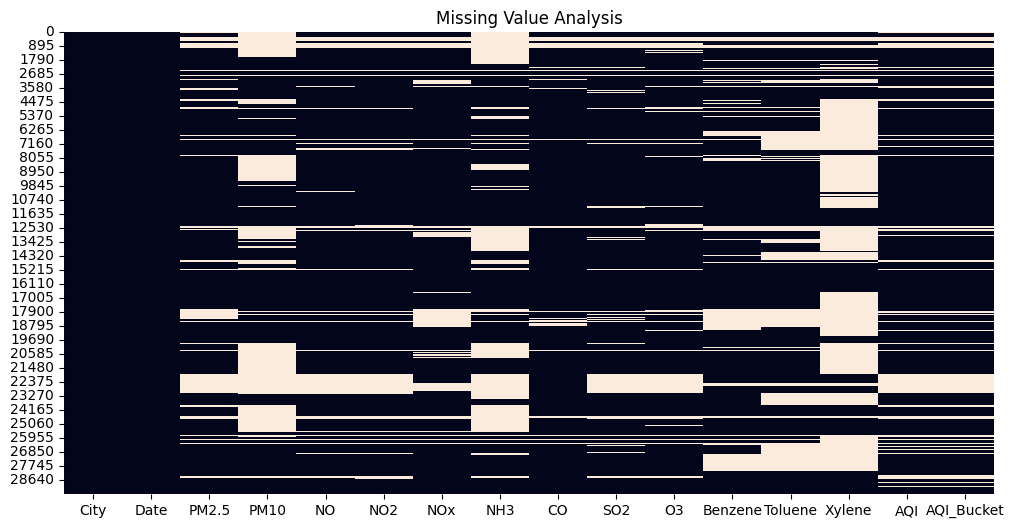

In [5]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Value Analysis")

plt.show()

In [6]:
missing_percent = round(
    (df.isnull().sum() / len(df)) * 100,
    2
)

missing_percent.sort_values(ascending=False)

Xylene        61.32
PM10          37.72
NH3           34.97
Toluene       27.23
Benzene       19.04
AQI           15.85
AQI_Bucket    15.85
PM2.5         15.57
NOx           14.17
O3            13.62
SO2           13.05
NO2           12.14
NO            12.13
CO             6.97
Date           0.00
City           0.00
dtype: float64

### Missing Values by City

Data quality may vary across monitoring locations.

This analysis identifies cities with the highest concentration of missing observations and helps assess whether data quality issues are localized.

In [ ]:
city_missing = (
    df.groupby('City')
      .apply(lambda x: x.isnull().sum().sum())
      .sort_values(ascending=False)
)

city_missing.head(15)

## AQI Validation
According to CPCB standards, AQI values range from 0 to 500.

Observations exceeding 500 are treated as invalid records and removed before analysis.


In [ ]:
df[df["AQI"] > 500]

In [ ]:
df = df[df["AQI"] <= 500]

## Feature Removal

The Xylene column contains a substantial proportion of missing values and contributes limited analytical value compared with other pollutants.

To improve dataset quality and simplify downstream analysis, the column is removed.

In [ ]:
df = df.drop(columns=['Xylene'])

## Missing Value Treatment

In [ ]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

### Why Median Imputation?

Median imputation helps retain valuable observations without being heavily influenced by outliers. Since pollutant concentrations can vary significantly during severe pollution events, the median provides a stable estimate of the typical pollutant level.

While imputation may slightly reduce natural variability, it allows meaningful correlation and trend analysis to be performed on a more complete dataset.


## Feature Engineering
- Year
- Month
- Week
- AQI Bucket

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
df["Year"] = df["Date"].dt.year

In [ ]:
df["Month"] = df["Date"].dt.month

In [ ]:
df["Week"] = df["Date"].dt.isocalendar().week

In [ ]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

df["AQI_Bucket"] = df["AQI"].apply(categorize_aqi)

In [ ]:
df["AQI_Bucket"].value_counts()

## Dataset Validation

Before exporting the cleaned dataset, a final validation is performed to ensure data quality.

The objective is to confirm:

* No invalid AQI values remain.
* The Xylene feature has been removed.
* Missing values have been handled appropriately.
* Newly created features exist and are correctly populated.


In [ ]:
df.shape

In [ ]:
df.columns.tolist()

In [ ]:
df.isnull().sum()

In [ ]:
df["AQI"].describe()

In [ ]:
df["AQI_Bucket"].value_counts()

## Dataset Transformation Summary

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Unique Cities",
        "Maximum AQI",
        "AQI Bucket Feature"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df["City"].nunique(),
        df["AQI"].max(),
        "Created"
    ]
})

summary

The preprocessing workflow successfully transformed the raw CPCB dataset into an analysis-ready dataset suitable for exploratory analysis, SQL querying, and dashboard development.

## Export Clean Dataset

After completing preprocessing and validation, the cleaned dataset is exported.

This dataset serves as the single source of truth for all subsequent project components:

* Data Understanding
* Temporal Analysis
* City Intelligence
* Pollutant Driver Analysis
* SQL Analytics
* Power BI Dashboard


In [ ]:
df.to_csv("cleaned_aqi.csv", index=False)
print("Cleaned dataset exported successfully.")
print("Dataset Shape:", df.shape)

# Conclusion

The raw CPCB dataset was transformed into a clean, analysis-ready dataset through a structured preprocessing workflow.

Key preprocessing steps included:

- AQI validation and removal of invalid observations
- Removal of low-quality features
- Missing value treatment
- Feature engineering
- Dataset validation

The resulting dataset provides a reliable foundation for subsequent analytical and visualization tasks.